# Mumbai Data - Spatial Analysis

Visualize where videos were collected geographically.

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap, MarkerCluster
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
BASE_DIR = Path('../..')
EXIF_DIR = BASE_DIR / 'exif_metadata'

GPS_TIMESERIES_FILES = [
    EXIF_DIR / '1_8_gps_timeseries.csv',
    EXIF_DIR / '9_11_gps_timeseries.csv',
    EXIF_DIR / '13_19_6_7_gps_timeseries_new.csv',
]

VIDEO_METADATA_FILES = [
    EXIF_DIR / '1_8_exif_video_metadata.csv',
    EXIF_DIR / '9_11_exif_video_metadata.csv',
    EXIF_DIR / '13_19_6_7_exif_video_metadata.csv',
]

MERGED_DATA_FILE = BASE_DIR / 'data/mumbai_annotations_with_exif.csv'

## Helper Functions

In [3]:
def dms_to_decimal(dms_str):
    """Convert DMS format to decimal degrees."""
    if pd.isna(dms_str):
        return None
    match = re.match(r"(\d+) deg (\d+)' ([\d.]+)\" ([NSEW])", str(dms_str))
    if match:
        d, m, s, direction = match.groups()
        decimal = float(d) + float(m)/60 + float(s)/3600
        if direction in ['S', 'W']:
            decimal = -decimal
        return decimal
    return None

## 1. Load GPS Timeseries Data

In [4]:
gps_dfs = []
for f in GPS_TIMESERIES_FILES:
    if f.exists():
        df = pd.read_csv(f)
        df['source_file'] = f.stem
        gps_dfs.append(df)
        print(f"{f.name}: {len(df):,} GPS points")

gps_data = pd.concat(gps_dfs, ignore_index=True)
print(f"\nTotal GPS points: {len(gps_data):,}")

1_8_gps_timeseries.csv: 630,753 GPS points
9_11_gps_timeseries.csv: 333,067 GPS points
13_19_6_7_gps_timeseries_new.csv: 426,313 GPS points

Total GPS points: 1,390,133


In [5]:
gps_data['lat'] = gps_data['gps_latitude'].apply(dms_to_decimal)
gps_data['lon'] = gps_data['gps_longitude'].apply(dms_to_decimal)

gps_valid = gps_data[gps_data['lat'].notna() & gps_data['lon'].notna()].copy()
print(f"Valid GPS points: {len(gps_valid):,}")

print(f"\nCoordinate ranges:")
print(f"  Latitude: {gps_valid['lat'].min():.4f} to {gps_valid['lat'].max():.4f}")
print(f"  Longitude: {gps_valid['lon'].min():.4f} to {gps_valid['lon'].max():.4f}")

Valid GPS points: 1,390,133

Coordinate ranges:
  Latitude: -25.5249 to 40.8999
  Longitude: 0.0000 to 98.9563


In [6]:
mumbai_lat_min, mumbai_lat_max = 18.85, 19.30
mumbai_lon_min, mumbai_lon_max = 72.75, 73.10

gps_mumbai = gps_valid[
    (gps_valid['lat'] >= mumbai_lat_min) & (gps_valid['lat'] <= mumbai_lat_max) &
    (gps_valid['lon'] >= mumbai_lon_min) & (gps_valid['lon'] <= mumbai_lon_max)
].copy()

print(f"GPS points within Mumbai region: {len(gps_mumbai):,}")
print(f"Points outside Mumbai (filtered): {len(gps_valid) - len(gps_mumbai):,}")

GPS points within Mumbai region: 1,387,893
Points outside Mumbai (filtered): 2,240


## 2. Load Video Metadata

In [7]:
video_dfs = []
for f in VIDEO_METADATA_FILES:
    if f.exists():
        df = pd.read_csv(f)
        video_dfs.append(df)

videos = pd.concat(video_dfs, ignore_index=True)
print(f"Total videos: {len(videos)}")

Total videos: 174


## 3. Route Map - All GPS Tracks

In [8]:
center_lat = gps_mumbai['lat'].mean()
center_lon = gps_mumbai['lon'].mean()

route_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='CartoDB positron'
)

source_colors = {
    '1_8_gps_timeseries': 'blue',
    '9_11_gps_timeseries': 'orange',
    '13_19_6_7_gps_timeseries_new': 'green'
}

video_ids = gps_mumbai['video_id'].unique()
print(f"Plotting routes for {len(video_ids)} videos...")

sample_rate = max(1, len(gps_mumbai) // 50000)
gps_sampled = gps_mumbai.iloc[::sample_rate]

for video_id in video_ids:
    video_gps = gps_sampled[gps_sampled['video_id'] == video_id].sort_values('gps_datetime')
    if len(video_gps) < 2:
        continue
    
    coords = list(zip(video_gps['lat'], video_gps['lon']))
    source = video_gps['source_file'].iloc[0]
    color = source_colors.get(source, 'gray')
    
    folium.PolyLine(
        coords,
        weight=2,
        color=color,
        opacity=0.6,
        popup=video_id
    ).add_to(route_map)

legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
            background-color: white; padding: 10px; border: 2px solid grey; border-radius: 5px;">
    <b>Source Folders</b><br>
    <i style="background: blue; width: 12px; height: 12px; display: inline-block;"></i> 1_8<br>
    <i style="background: orange; width: 12px; height: 12px; display: inline-block;"></i> 9_11<br>
    <i style="background: green; width: 12px; height: 12px; display: inline-block;"></i> 13_19_6_7
</div>
'''
route_map.get_root().html.add_child(folium.Element(legend_html))

route_map

Plotting routes for 171 videos...


In [9]:
route_map.save(str(BASE_DIR / 'output/mumbai_route_map.html'))
print(f"Route map saved to {BASE_DIR / 'output/mumbai_route_map.html'}")

Route map saved to ../../output/mumbai_route_map.html


## 4. GPS Point Density Heatmap

In [10]:
heat_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

sample_rate = max(1, len(gps_mumbai) // 20000)
heat_data = gps_mumbai.iloc[::sample_rate][['lat', 'lon']].values.tolist()

HeatMap(
    heat_data,
    min_opacity=0.3,
    radius=8,
    blur=10,
    gradient={0.4: 'blue', 0.6: 'lime', 0.8: 'yellow', 1: 'red'}
).add_to(heat_map)

heat_map

In [11]:
heat_map.save(str(BASE_DIR / 'output/mumbai_heatmap.html'))
print(f"Heatmap saved to {BASE_DIR / 'output/mumbai_heatmap.html'}")

Heatmap saved to ../../output/mumbai_heatmap.html


## 5. Video Start/End Points

In [12]:
start_end_points = []

for video_id in gps_mumbai['video_id'].unique():
    video_gps = gps_mumbai[gps_mumbai['video_id'] == video_id].sort_values('gps_datetime')
    if len(video_gps) < 2:
        continue
    
    start = video_gps.iloc[0]
    end = video_gps.iloc[-1]
    
    start_end_points.append({
        'video_id': video_id,
        'type': 'start',
        'lat': start['lat'],
        'lon': start['lon']
    })
    start_end_points.append({
        'video_id': video_id,
        'type': 'end',
        'lat': end['lat'],
        'lon': end['lon']
    })

start_end_df = pd.DataFrame(start_end_points)
print(f"Start/end points: {len(start_end_df)}")

Start/end points: 342


In [13]:
startend_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles='CartoDB positron'
)

for _, row in start_end_df.iterrows():
    color = 'green' if row['type'] == 'start' else 'red'
    icon = 'play' if row['type'] == 'start' else 'stop'
    
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=5,
        color=color,
        fill=True,
        fillOpacity=0.7,
        popup=f"{row['video_id']} ({row['type']})"
    ).add_to(startend_map)

legend_html = '''
<div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000; 
            background-color: white; padding: 10px; border: 2px solid grey; border-radius: 5px;">
    <b>Markers</b><br>
    <i style="background: green; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> Start<br>
    <i style="background: red; width: 12px; height: 12px; display: inline-block; border-radius: 50%;"></i> End
</div>
'''
startend_map.get_root().html.add_child(folium.Element(legend_html))

startend_map

## 6. Annotated Frame Locations

In [14]:
if MERGED_DATA_FILE.exists():
    annotations = pd.read_csv(MERGED_DATA_FILE)
    print(f"Loaded {len(annotations)} annotations")
    print(f"With GPS coordinates: {annotations['gps_lat'].notna().sum()}")
    print(f"\nBy region:")
    print(annotations['region'].value_counts())
    print(f"\nGPS coverage by region:")
    for region in annotations['region'].unique():
        region_df = annotations[annotations['region'] == region]
        gps_count = region_df['gps_lat'].notna().sum()
        gps_pct = 100 * gps_count / len(region_df) if len(region_df) > 0 else 0
        print(f"  {region}: {gps_count}/{len(region_df)} ({gps_pct:.1f}%)")
else:
    print(f"Merged data file not found: {MERGED_DATA_FILE}")
    print("Run preprocess_mumbai.ipynb first to create the merged dataset.")
    annotations = None

Loaded 4000 annotations
With GPS coordinates: 3447

By region:
region
mumbai         2744
navi_mumbai    1256
Name: count, dtype: int64

GPS coverage by region:
  mumbai: 2226/2744 (81.1%)
  navi_mumbai: 1221/1256 (97.2%)


In [15]:
if annotations is not None and annotations['gps_lat'].notna().any():
    annot_with_gps = annotations[annotations['gps_lat'].notna()].copy()
    
    # Filter for Mumbai only
    mumbai_annot = annot_with_gps[annot_with_gps['region'] == 'mumbai'].copy()
    
    annot_map = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=12,
        tiles='CartoDB positron'
    )
    
    marker_cluster = MarkerCluster().add_to(annot_map)
    
    for _, row in mumbai_annot.iterrows():
        women_count = row.get('women_count', 0) if pd.notna(row.get('women_count')) else 0
        men_count = row.get('men_count', 0) if pd.notna(row.get('men_count')) else 0
        
        ratio_str = f"{women_count/men_count:.2f}" if men_count > 0 else "N/A"
        popup_text = f"""<b>Frame:</b> {row.get('base_video_id', 'N/A')}<br>
        <b>Women:</b> {women_count}<br>
        <b>Men:</b> {men_count}<br>
        <b>Ratio:</b> {ratio_str}"""
        
        folium.CircleMarker(
            location=[row['gps_lat'], row['gps_lon']],
            radius=5,
            color='#3498db',
            fill=True,
            fillOpacity=0.7,
            popup=popup_text
        ).add_to(marker_cluster)
    
    display(annot_map)
    
    annot_map.save(str(BASE_DIR / 'output/mumbai_annotations_map.html'))
    print(f"Mumbai annotations map saved to {BASE_DIR / 'output/mumbai_annotations_map.html'}")
else:
    print("No annotations with GPS coordinates available.")

Mumbai annotations map saved to ../../output/mumbai_annotations_map.html


## 6b. Navi Mumbai Annotations Map

In [16]:
if annotations is not None and annotations['gps_lat'].notna().any():
    navi_annot = annot_with_gps[annot_with_gps['region'] == 'navi_mumbai'].copy()
    
    navi_center_lat = navi_annot['gps_lat'].mean()
    navi_center_lon = navi_annot['gps_lon'].mean()
    
    navi_annot_map = folium.Map(
        location=[navi_center_lat, navi_center_lon],
        zoom_start=13,
        tiles='CartoDB positron'
    )
    
    marker_cluster = MarkerCluster().add_to(navi_annot_map)
    
    for _, row in navi_annot.iterrows():
        women_count = row.get('women_count', 0) if pd.notna(row.get('women_count')) else 0
        men_count = row.get('men_count', 0) if pd.notna(row.get('men_count')) else 0
        
        ratio_str = f"{women_count/men_count:.2f}" if men_count > 0 else "N/A"
        popup_text = f"""<b>Frame:</b> {row.get('base_video_id', 'N/A')}<br>
        <b>Women:</b> {women_count}<br>
        <b>Men:</b> {men_count}<br>
        <b>Ratio:</b> {ratio_str}"""
        
        folium.CircleMarker(
            location=[row['gps_lat'], row['gps_lon']],
            radius=5,
            color='#e74c3c',
            fill=True,
            fillOpacity=0.7,
            popup=popup_text
        ).add_to(marker_cluster)
    
    display(navi_annot_map)
    
    navi_annot_map.save(str(BASE_DIR / 'output/navi_mumbai_annotations_map.html'))
    print(f"Navi Mumbai annotations map saved to {BASE_DIR / 'output/navi_mumbai_annotations_map.html'}")
else:
    print("No annotations with GPS coordinates available.")

Navi Mumbai annotations map saved to ../../output/navi_mumbai_annotations_map.html


## 6c. Sex Ratio Heatmaps

Heatmaps weighted by the proportion of women at each location.

In [17]:
def create_sex_ratio_heatmap(df, center_lat, center_lon, output_path, zoom=13):
    """Create a kernel density heatmap weighted by sex ratio."""
    
    df_with_people = df[
        (df['total_people'] > 0) & 
        df['gps_lat'].notna() & 
        df['prop_women'].notna()
    ].copy()
    
    heat_data = [
        [row['gps_lat'], row['gps_lon'], row['prop_women']]
        for _, row in df_with_people.iterrows()
    ]
    
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=zoom,
        tiles='CartoDB dark_matter'
    )
    
    HeatMap(
        heat_data,
        min_opacity=0.5,
        radius=15,
        blur=10,
        gradient={0.0: 'red', 0.25: 'orange', 0.5: 'yellow', 0.75: 'lightgreen', 1.0: 'green'}
    ).add_to(m)
    
    legend_html = '''
    <div style="position: fixed; bottom: 50px; left: 50px; z-index: 1000;
                background-color: white; padding: 10px; border: 2px solid grey; border-radius: 5px;">
        <b>Proportion Women</b><br>
        <div style="background: linear-gradient(to right, red, orange, yellow, lightgreen, green);
                    width: 100px; height: 15px; margin: 5px 0;"></div>
        <div style="display: flex; justify-content: space-between; width: 100px; font-size: 10px;">
            <span>0.0</span><span>0.5</span><span>1.0</span>
        </div>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))
    
    m.save(str(output_path))
    print(f"Saved: {output_path}")
    return m

In [18]:
if annotations is not None:
    annot_with_gps['total_people'] = annot_with_gps['women_count'].fillna(0) + annot_with_gps['men_count'].fillna(0)
    annot_with_gps['prop_women'] = annot_with_gps['women_count'].fillna(0) / annot_with_gps['total_people']
    annot_with_gps['prop_women'] = annot_with_gps['prop_women'].replace([np.inf, -np.inf], np.nan)
    
    mumbai_annot = annot_with_gps[annot_with_gps['region'] == 'mumbai']
    mumbai_heatmap = create_sex_ratio_heatmap(
        mumbai_annot, center_lat, center_lon,
        BASE_DIR / 'output/mumbai_sex_ratio_heatmap.html',
        zoom=12
    )
    display(mumbai_heatmap)

Saved: ../../output/mumbai_sex_ratio_heatmap.html


In [19]:
if annotations is not None:
    navi_annot = annot_with_gps[annot_with_gps['region'] == 'navi_mumbai']
    navi_center_lat = navi_annot['gps_lat'].mean()
    navi_center_lon = navi_annot['gps_lon'].mean()
    
    navi_heatmap = create_sex_ratio_heatmap(
        navi_annot, navi_center_lat, navi_center_lon,
        BASE_DIR / 'output/navi_mumbai_sex_ratio_heatmap.html',
        zoom=13
    )
    display(navi_heatmap)

Saved: ../../output/navi_mumbai_sex_ratio_heatmap.html


## 7. Static Scatter Plot

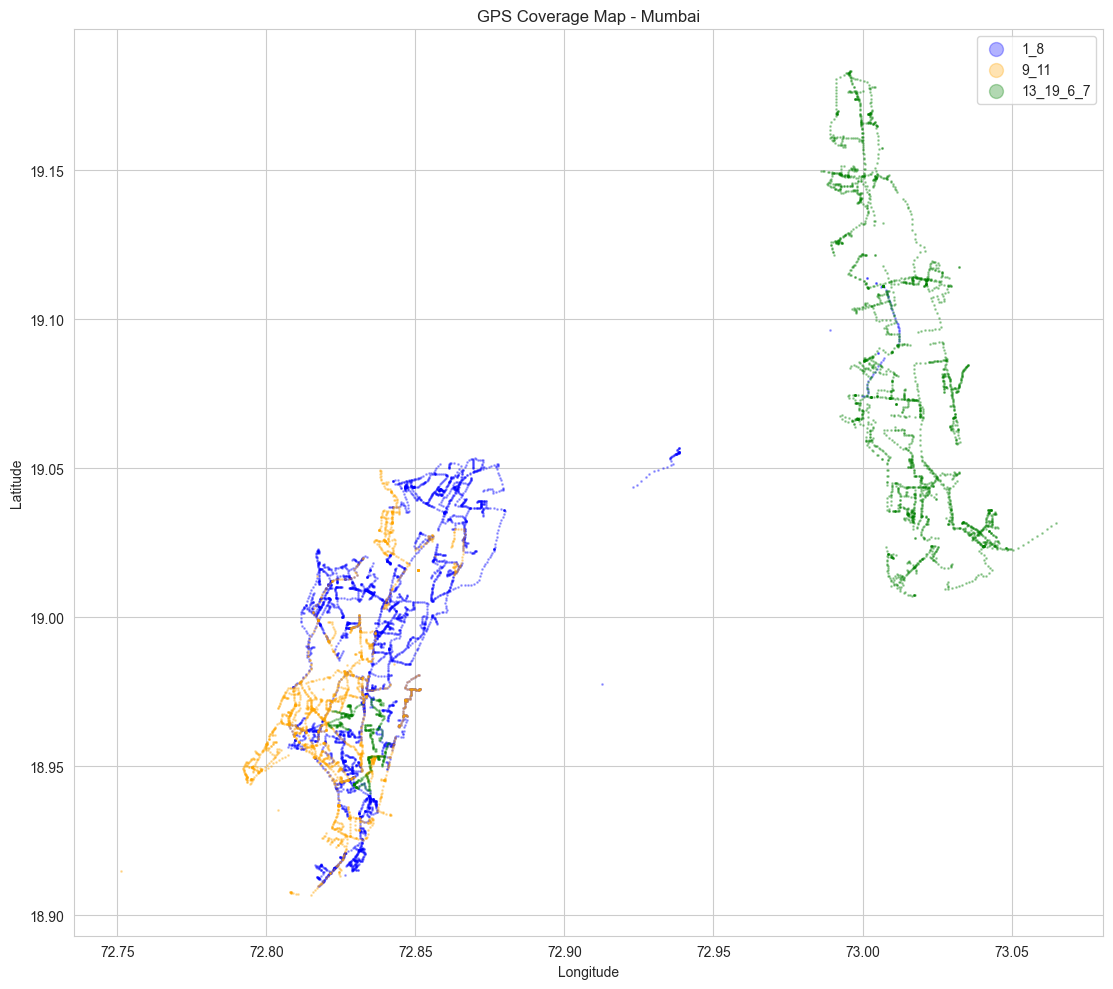

In [20]:
fig, ax = plt.subplots(figsize=(12, 10))

sample_rate = max(1, len(gps_mumbai) // 10000)
gps_plot = gps_mumbai.iloc[::sample_rate]

for source, color in source_colors.items():
    source_data = gps_plot[gps_plot['source_file'] == source]
    ax.scatter(
        source_data['lon'], source_data['lat'],
        c=color, alpha=0.3, s=1,
        label=source.replace('_gps_timeseries', '').replace('_new', '')
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('GPS Coverage Map - Mumbai')
ax.legend(markerscale=10)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

## 8. Coverage Statistics

In [21]:
print("=" * 50)
print("SPATIAL COVERAGE SUMMARY")
print("=" * 50)

print(f"\nGPS Data:")
print(f"  Total GPS points: {len(gps_data):,}")
print(f"  Valid GPS points: {len(gps_valid):,}")
print(f"  Points in Mumbai region: {len(gps_mumbai):,}")
print(f"  Unique videos with GPS: {gps_mumbai['video_id'].nunique()}")

print(f"\nGeographic Bounds (Mumbai region):")
print(f"  Latitude: {gps_mumbai['lat'].min():.4f} to {gps_mumbai['lat'].max():.4f}")
print(f"  Longitude: {gps_mumbai['lon'].min():.4f} to {gps_mumbai['lon'].max():.4f}")

print(f"\nCenter Point:")
print(f"  Latitude: {gps_mumbai['lat'].mean():.4f}")
print(f"  Longitude: {gps_mumbai['lon'].mean():.4f}")

if annotations is not None:
    print(f"\nAnnotation Coverage:")
    print(f"  Total annotations: {len(annotations)}")
    print(f"  With GPS coordinates: {annotations['gps_lat'].notna().sum()}")
    print(f"\n  By Region:")
    for region in annotations['region'].unique():
        region_df = annotations[annotations['region'] == region]
        with_gps = region_df['gps_lat'].notna().sum()
        print(f"    {region}: {with_gps}/{len(region_df)} with GPS")

SPATIAL COVERAGE SUMMARY

GPS Data:
  Total GPS points: 1,390,133
  Valid GPS points: 1,390,133
  Points in Mumbai region: 1,387,893
  Unique videos with GPS: 171

Geographic Bounds (Mumbai region):
  Latitude: 18.9068 to 19.1834
  Longitude: 72.7508 to 73.0651

Center Point:
  Latitude: 19.0096
  Longitude: 72.8830

Annotation Coverage:
  Total annotations: 4000
  With GPS coordinates: 3447

  By Region:
    mumbai: 2226/2744 with GPS
    navi_mumbai: 1221/1256 with GPS


In [22]:
source_stats = gps_mumbai.groupby('source_file').agg({
    'video_id': 'nunique',
    'lat': ['count', 'min', 'max'],
    'lon': ['min', 'max']
}).round(4)

source_stats.columns = ['unique_videos', 'gps_points', 'lat_min', 'lat_max', 'lon_min', 'lon_max']

print("\nCoverage by Source:")
print(source_stats)


Coverage by Source:
                              unique_videos  gps_points  lat_min  lat_max  \
source_file                                                                 
13_19_6_7_gps_timeseries_new             49      425904  18.9410  19.1834   
1_8_gps_timeseries                       82      629656  18.9096  19.1137   
9_11_gps_timeseries                      40      332333  18.9068  19.0495   

                              lon_min  lon_max  
source_file                                     
13_19_6_7_gps_timeseries_new  72.8203  73.0651  
1_8_gps_timeseries            72.8072  73.0124  
9_11_gps_timeseries           72.7508  72.8666  
